# 07 — Perfil del contratista y concentracion del mercado

**Proposito.** Incorporar el bloque de proveedor, ausente del EDA descriptivo previo: `es_pyme`
(disponible al 100% en el contrato y sin usar hasta ahora), tipo de empresa, antiguedad y categoria
UNSPSC del registro de proveedores, y la concentracion de contratos por contratista. Cierra la brecha 7
del documento comparativo y aporta el perfil de proveedor que el insight N-K02 pedia para profundizar
A-H2.

**Insumo.** `data/universo_extendido.parquet` (notebook 01).

**Etiquetas de objetivo que atiende:** `[A-OE04]` (segmentacion por contratista), `[A-H2]` (perfil de
contratista para la hipotesis de consorcios), `[B-OE2]` (variables criticas y comportamiento historico),
`[B-OE3-insumo]`, `[CALIDAD]`.

**Limitacion declarada de entrada.** El registro externo de proveedores cubre el 54,41% de los
proveedores unicos y el 66,47% de los contratos. Los analisis que dependen de `tipo_empresa`,
`antiguedad` o UNSPSC del proveedor se reportan sobre ese subconjunto, con su N efectivo. Los analisis
basados en `es_pyme` y `tipo_contratista` cubren el 100% porque se derivan del propio contrato.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
obs = df[df["observable"]].copy()
print(f"Universo: {len(df):,} | Observable: {len(obs):,}")
cob = pd.DataFrame({
    "variable": ["es_pyme (contrato)", "tipo_contratista (derivada del contrato)",
                 "prov_tipo_empresa (registro)", "prov_espyme (registro)",
                 "antiguedad_proveedor_anios (registro)", "prov_codigo_categoria_principal (registro)"],
    "cobertura_pct": [round(df[c].notna().mean() * 100, 2) for c in
                      ["es_pyme", "tipo_contratista", "prov_tipo_empresa", "prov_espyme",
                       "antiguedad_proveedor_anios", "prov_codigo_categoria_principal"]],
})
cob

Universo: 48,331 | Observable: 19,194


,variable,cobertura_pct
0,es_pyme (contrato),100.0000
1,tipo_contratista (derivada del contrato),100.0000
2,prov_tipo_empresa (registro),66.4700
3,prov_espyme (registro),66.4700
4,antiguedad_proveedor_anios (registro),59.8900
5,prov_codigo_categoria_principal (registro),66.4700


## 1. `es_pyme`: la variable disponible al 100% que no se habia usado

In [3]:
marcar("pyme")

def perfil_pyme(x):
    g = x.groupby("es_pyme")
    return pd.DataFrame({
        "n": g.size(),
        "pct": (g.size() / len(x) * 100).round(2),
        "mediana_valor": g["valor_del_contrato"].median(),
        "n_ef_tiempo": g["deslizamiento_plazo_dias"].apply(lambda s: int(s.notna().sum())),
        "mediana_deslizamiento": g["deslizamiento_plazo_dias"].median(),
        "pct_retraso_mayor_30": g["deslizamiento_plazo_dias"].apply(
            lambda s: round((s.dropna() > 30).mean() * 100, 1)),
        "n_ef_costo": g["desviacion_costo_pct"].apply(lambda s: int(s.notna().sum())),
        "mediana_costo": g["desviacion_costo_pct"].median().round(3),
        "pct_no_entregado": g["indice_alcance"].apply(lambda s: round((s == "No entregado").mean() * 100, 1)),
        "mediana_modificaciones": g["n_modificaciones_total"].median(),
        "mediana_oferentes": g["n_oferentes"].median(),
    })

print("=== UNIVERSO COMPLETO ==="); print(perfil_pyme(df).to_string())
print()
print("=== SUBCONJUNTO OBSERVABLE ==="); print(perfil_pyme(obs).to_string())
print()
for var, nombre in [("deslizamiento_plazo_dias", "deslizamiento del plazo"),
                    ("desviacion_costo_pct", "desviacion de costo"),
                    ("n_modificaciones_total", "numero de modificaciones")]:
    r = mann_whitney(obs.loc[obs["es_pyme"] == "Si", var],
                     obs.loc[obs["es_pyme"] == "No", var], "PYME", "No PYME")
    print(f"{nombre}:"); print(" ", resumen_prueba(r)); print()
tab = pd.crosstab(obs["es_pyme"], obs["indice_alcance"])
print("Chi-cuadrado, es_pyme x indice de alcance (observable):")
print(" ", resumen_prueba(cramers_v(tab)))

=== UNIVERSO COMPLETO ===
             n     pct    mediana_valor  n_ef_tiempo  mediana_deslizamiento  pct_retraso_mayor_30  n_ef_costo  mediana_costo  pct_no_entregado  mediana_modificaciones  mediana_oferentes
es_pyme                                                                                                                                                                                  
No       20862 43.1600 270,904,219.5000        16040                 3.0000               31.1000        6235         0.0000           10.1000                  2.0000             0.0000
Si       27469 56.8400 181,724,833.0000        21115                 0.0000               19.8000        8800        -0.0000           10.8000                  2.0000             3.0000

=== SUBCONJUNTO OBSERVABLE ===
             n     pct    mediana_valor  n_ef_tiempo  mediana_deslizamiento  pct_retraso_mayor_30  n_ef_costo  mediana_costo  pct_no_entregado  mediana_modificaciones  mediana_oferentes
es_pyme     

Nota de coherencia entre fuentes: `es_pyme` del contrato y `espyme` del registro de proveedores tienen
nombres casi identicos y podrian no medir lo mismo. Antes de tratarlas como equivalentes se comprueba su
concordancia empirica sobre los contratos donde ambas estan disponibles.

In [4]:
marcar("pyme_coherencia")

comp = df[df["prov_espyme"].notna()].copy()
comp["reg"] = comp["prov_espyme"].str.upper().map({"SI": "Si", "NO": "No"})
tab = pd.crosstab(comp["es_pyme"], comp["reg"], margins=True)
print("Concordancia entre `es_pyme` (contrato) y `espyme` (registro de proveedores):")
print(tab.to_string())
concordan = (comp["es_pyme"] == comp["reg"]).mean() * 100
print()
print(f"N efectivo: {len(comp):,} contratos con ambas variables disponibles")
print(f"Concordancia: {concordan:.2f}%")
print()
print("RESULTADO: la concordancia es perfecta donde ambas estan disponibles. No son variables en")
print("conflicto sino la misma variable con coberturas distintas. Se adopta `es_pyme` del contrato")
print("como variable de trabajo por cobertura del 100% frente al 66.47% del registro externo.")
print()
print("Cobertura de la antiguedad por tipo de contratista (advertencia estructural):")
print(df.groupby("tipo_contratista")["antiguedad_proveedor_anios"]
      .apply(lambda s: round(s.notna().mean() * 100, 2)).to_frame("cobertura_antiguedad_pct").to_string())
print()
print("Los consorcios y uniones temporales no figuran en el registro de proveedores con fecha de")
print("creacion utilizable, de modo que la antiguedad no es calculable para ese tipo de contratista.")
print("Cualquier analisis de antiguedad esta por construccion sesgado a personas juridicas y naturales.")

Concordancia entre `es_pyme` (contrato) y `espyme` (registro de proveedores):
reg        No     Si    All
es_pyme                    
No       8131      0   8131
Si          0  23995  23995
All      8131  23995  32126

N efectivo: 32,126 contratos con ambas variables disponibles
Concordancia: 100.00%

RESULTADO: la concordancia es perfecta donde ambas estan disponibles. No son variables en
conflicto sino la misma variable con coberturas distintas. Se adopta `es_pyme` del contrato
como variable de trabajo por cobertura del 100% frente al 66.47% del registro externo.

Cobertura de la antiguedad por tipo de contratista (advertencia estructural):
                            cobertura_antiguedad_pct
tipo_contratista                                    
Consorcio / Union Temporal                    0.0000
No definido                                  26.8800
Persona Juridica                             75.9200
Persona Natural                              88.1500

Los consorcios y uniones tempo

## 2. Tipo de contratista y perfil del proveedor registrado

In [5]:
marcar("tipo_contratista")

def perfil_tc(x):
    g = x.groupby("tipo_contratista")
    return pd.DataFrame({
        "n": g.size(), "pct": (g.size() / len(x) * 100).round(2),
        "mediana_valor": g["valor_del_contrato"].median(),
        "mediana_modificaciones": g["n_modificaciones_total"].median(),
        "mediana_deslizamiento": g["deslizamiento_plazo_dias"].median(),
        "pct_no_entregado": g["indice_alcance"].apply(lambda s: round((s == "No entregado").mean()*100, 1)),
        "pct_entregado_total": g["indice_alcance"].apply(lambda s: round((s == "Entregado en su totalidad").mean()*100, 1)),
        "mediana_oferentes": g["n_oferentes"].median(),
        "pct_pyme": g["es_pyme"].apply(lambda s: round((s == "Si").mean()*100, 1)),
        "mediana_antiguedad_anios": g["antiguedad_proveedor_anios"].median().round(2),
    })

print("=== UNIVERSO COMPLETO ==="); print(perfil_tc(df).to_string())
print()
print("=== SUBCONJUNTO OBSERVABLE ==="); print(perfil_tc(obs).to_string())

=== UNIVERSO COMPLETO ===
                                n     pct      mediana_valor  mediana_modificaciones  mediana_deslizamiento  pct_no_entregado  pct_entregado_total  mediana_oferentes  pct_pyme  mediana_antiguedad_anios
tipo_contratista                                                                                                                                                                                         
Consorcio / Union Temporal  10629 21.9900 1,542,231,047.0000                  3.0000                 8.0000            6.2000              62.0000             5.0000   32.6000                       NaN
No definido                   971  2.0100             0.0000                  0.0000                 0.0000            4.9000              92.0000             0.0000   25.6000                    2.6000
Persona Juridica            30197 62.4800   119,470,000.0000                  1.0000                 1.0000           12.1000              75.7000             1.0000 

In [6]:
marcar("tipo_empresa")

sub = obs[obs["prov_tipo_empresa"].notna()]
print(f"N efectivo con tipo de empresa del registro: {len(sub):,} "
      f"({len(sub)/len(obs)*100:.1f}% del subconjunto observable)")
print()
te = (sub.groupby("prov_tipo_empresa")
      .agg(n=("id_contrato", "size"),
           mediana_valor=("valor_del_contrato", "median"),
           mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
           pct_retraso_mayor_30=("deslizamiento_plazo_dias", lambda s: round((s.dropna() > 30).mean()*100, 1)),
           pct_no_entregado=("indice_alcance", lambda s: round((s == "No entregado").mean()*100, 1)),
           mediana_modificaciones=("n_modificaciones_total", "median"))
      .sort_values("n", ascending=False).head(8))
print(te.to_string())
print()
principales = te.index.tolist()
g = {k: v["deslizamiento_plazo_dias"].dropna() for k, v in
     sub[sub["prov_tipo_empresa"].isin(principales)].groupby("prov_tipo_empresa")}
print("Kruskal-Wallis, deslizamiento del plazo entre tipos de empresa (top 8):")
print(" ", resumen_prueba(kruskal(g)))

N efectivo con tipo de empresa del registro: 12,527 (65.3% del subconjunto observable)

                                                    n    mediana_valor  mediana_deslizamiento  pct_retraso_mayor_30  pct_no_entregado  mediana_modificaciones
prov_tipo_empresa                                                                                                                                            
SOCIEDAD POR ACCIONES SIMPLIFICADA               5910 190,105,848.5000                 1.0000               22.1000           22.1000                  3.0000
PERSONA NATURAL COLOMBIANA                       2479 130,333,030.0000                 0.0000               21.6000           22.4000                  3.0000
OTRO                                             1194  87,203,978.0000                 0.0000               17.8000           19.3000                  2.0000
ENTIDADES SIN aNIMO DE LUCRO                      754  31,948,589.5000                 0.0000               15.8000       

In [7]:
marcar("antiguedad")

sub = df[df["antiguedad_proveedor_anios"].notna() & (df["antiguedad_proveedor_anios"] >= 0)].copy()
BINS_ANT = [0, 1, 3, 5, np.inf]
ETIQ_ANT = ["<1 anio", "1-3 anios", "3-5 anios", ">5 anios"]
sub["antiguedad_cat"] = pd.cut(sub["antiguedad_proveedor_anios"], bins=BINS_ANT,
                               labels=ETIQ_ANT, include_lowest=True)
print(f"N efectivo con antiguedad calculable: {len(sub):,} ({len(sub)/len(df)*100:.1f}% del universo)")
print("Advertencia de calidad: `fecha_creacion` del registro es la fecha de creacion de la CUENTA en")
print("SECOP, no la fecha de constitucion de la empresa. La antiguedad medida es antiguedad en la")
print("plataforma. Se reporta como tal y no como experiencia empresarial.")
print()
ant = (sub.groupby("antiguedad_cat", observed=True)
       .agg(n=("id_contrato", "size"),
            mediana_valor=("valor_del_contrato", "median"),
            mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
            pct_no_entregado=("indice_alcance", lambda s: round((s == "No entregado").mean()*100, 1)),
            mediana_modificaciones=("n_modificaciones_total", "median"),
            pct_consorcio=("tipo_contratista", lambda s: round((s == "Consorcio / Union Temporal").mean()*100, 1)))
       .reindex(ETIQ_ANT))
print(ant.to_string())
print()
sp = spearman(sub["antiguedad_proveedor_anios"], sub["deslizamiento_plazo_dias"])
print(f"Spearman antiguedad ~ deslizamiento: rho = {sp['rho']:.4f}, N efectivo = {sp['n_efectivo']:,} ({sp['efecto']})")
sp = spearman(sub["antiguedad_proveedor_anios"], sub["n_modificaciones_total"])
print(f"Spearman antiguedad ~ modificaciones: rho = {sp['rho']:.4f}, N efectivo = {sp['n_efectivo']:,} ({sp['efecto']})")

N efectivo con antiguedad calculable: 28,896 (59.8% del universo)
Advertencia de calidad: `fecha_creacion` del registro es la fecha de creacion de la CUENTA en
SECOP, no la fecha de constitucion de la empresa. La antiguedad medida es antiguedad en la
plataforma. Se reporta como tal y no como experiencia empresarial.



                   n    mediana_valor  mediana_deslizamiento  pct_no_entregado  mediana_modificaciones  pct_consorcio
antiguedad_cat                                                                                                       
<1 anio         7478  49,888,843.0000                 0.0000           15.9000                  1.0000         0.0000
1-3 anios       8361  99,996,983.0000                 0.0000           15.5000                  2.0000         0.0000
3-5 anios       6930 172,860,929.0000                 0.0000           11.4000                  2.0000         0.0000
>5 anios        6127 250,000,000.0000                 0.0000            5.6000                  2.0000         0.0000



Spearman antiguedad ~ deslizamiento: rho = 0.0745, N efectivo = 24,503 (nulo)
Spearman antiguedad ~ modificaciones: rho = 0.1044, N efectivo = 28,896 (pequeno)


## 3. Concentracion de contratos por contratista y reincidencia

In [8]:
marcar("concentracion")

conteo = df.groupby("codigo_proveedor")["id_contrato"].size().sort_values(ascending=False)
valor = df.groupby("codigo_proveedor")["valor_del_contrato"].sum().sort_values(ascending=False)
n_prov = len(conteo)

def cuota(serie, frac):
    k = max(1, int(round(len(serie) * frac)))
    return round(serie.head(k).sum() / serie.sum() * 100, 2)

conc = pd.DataFrame({
    "corte": ["Top 10 proveedores", "Top 1% de proveedores", "Top 5% de proveedores",
              "Top 10% de proveedores", "Top 20% de proveedores"],
    "n_proveedores": [10, max(1, int(n_prov*0.01)), max(1, int(n_prov*0.05)),
                      max(1, int(n_prov*0.10)), max(1, int(n_prov*0.20))],
    "cuota_de_contratos_pct": [round(conteo.head(10).sum()/conteo.sum()*100, 2), cuota(conteo, .01),
                               cuota(conteo, .05), cuota(conteo, .10), cuota(conteo, .20)],
    "cuota_de_valor_pct": [round(valor.head(10).sum()/valor.sum()*100, 2), cuota(valor, .01),
                           cuota(valor, .05), cuota(valor, .10), cuota(valor, .20)],
})
print(f"Proveedores unicos en el universo: {n_prov:,}")
print(conc.to_string(index=False))
print()
print("Distribucion de contratos por proveedor:")
print(f"  mediana: {conteo.median():.0f} | p90: {conteo.quantile(.9):.0f} | "
      f"p99: {conteo.quantile(.99):.0f} | maximo: {conteo.max():,}")
print(f"  proveedores con un unico contrato: {int((conteo == 1).sum()):,} ({(conteo == 1).mean()*100:.1f}%)")
print()
print("El mercado NO esta concentrado en el sentido clasico: el 20% de los proveedores concentra")
print("una cuota alta, pero no hay un puñado de contratistas dominantes. La cola larga es lo dominante.")

Proveedores unicos en el universo: 23,192
                 corte  n_proveedores  cuota_de_contratos_pct  cuota_de_valor_pct
    Top 10 proveedores             10                  2.7300             16.5900
 Top 1% de proveedores            231                 15.1400             47.0200
 Top 5% de proveedores           1159                 33.1300             70.6800
Top 10% de proveedores           2319                 44.2200             81.5800
Top 20% de proveedores           4638                 56.9400             91.0800

Distribucion de contratos por proveedor:
  mediana: 1 | p90: 4 | p99: 17 | maximo: 672
  proveedores con un unico contrato: 16,299 (70.3%)

El mercado NO esta concentrado en el sentido clasico: el 20% de los proveedores concentra
una cuota alta, pero no hay un puñado de contratistas dominantes. La cola larga es lo dominante.


In [9]:
marcar("reincidencia")

df2 = df.copy()
df2["n_contratos_del_proveedor"] = df2["codigo_proveedor"].map(conteo)
BINS_R = [0, 1, 3, 10, np.inf]
ETIQ_R = ["1 contrato", "2-3 contratos", "4-10 contratos", ">10 contratos"]
df2["reincidencia_cat"] = pd.cut(df2["n_contratos_del_proveedor"], bins=BINS_R, labels=ETIQ_R)
obs2 = df2[df2["observable"]]

def perfil_reinc(x):
    return (x.groupby("reincidencia_cat", observed=True)
            .agg(contratos=("id_contrato", "size"),
                 mediana_valor=("valor_del_contrato", "median"),
                 mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
                 pct_retraso_mayor_30=("deslizamiento_plazo_dias", lambda s: round((s.dropna() > 30).mean()*100, 1)),
                 pct_no_entregado=("indice_alcance", lambda s: round((s == "No entregado").mean()*100, 1)),
                 mediana_modificaciones=("n_modificaciones_total", "median"),
                 pct_consorcio=("tipo_contratista", lambda s: round((s == "Consorcio / Union Temporal").mean()*100, 1)))
            .reindex(ETIQ_R))

print("=== UNIVERSO COMPLETO ==="); print(perfil_reinc(df2).to_string())
print()
print("=== SUBCONJUNTO OBSERVABLE ==="); print(perfil_reinc(obs2).to_string())
print()
g = {k: v["deslizamiento_plazo_dias"].dropna() for k, v in
     obs2[obs2["reincidencia_cat"].notna()].groupby("reincidencia_cat", observed=True)}
print("Kruskal-Wallis, deslizamiento del plazo entre niveles de reincidencia (observable):")
print(" ", resumen_prueba(kruskal(g)))
tab = pd.crosstab(obs2["reincidencia_cat"], obs2["indice_alcance"])
print("Chi-cuadrado, reincidencia x indice de alcance (observable):")
print(" ", resumen_prueba(cramers_v(tab)))

=== UNIVERSO COMPLETO ===
                  contratos    mediana_valor  mediana_deslizamiento  pct_retraso_mayor_30  pct_no_entregado  mediana_modificaciones  pct_consorcio
reincidencia_cat                                                                                                                                  
1 contrato            16299 470,931,228.0000                 1.0000               30.1000            7.3000                  2.0000        52.3000
2-3 contratos         10265 177,970,195.0000                 0.0000               22.6000           11.0000                  1.0000        16.3000
4-10 contratos        10907 171,473,421.0000                 0.0000               19.9000           11.0000                  2.0000         3.9000
>10 contratos         10860 100,063,346.0000                 2.0000               22.5000           14.4000                  1.0000         0.1000

=== SUBCONJUNTO OBSERVABLE ===
                  contratos    mediana_valor  mediana_desliz

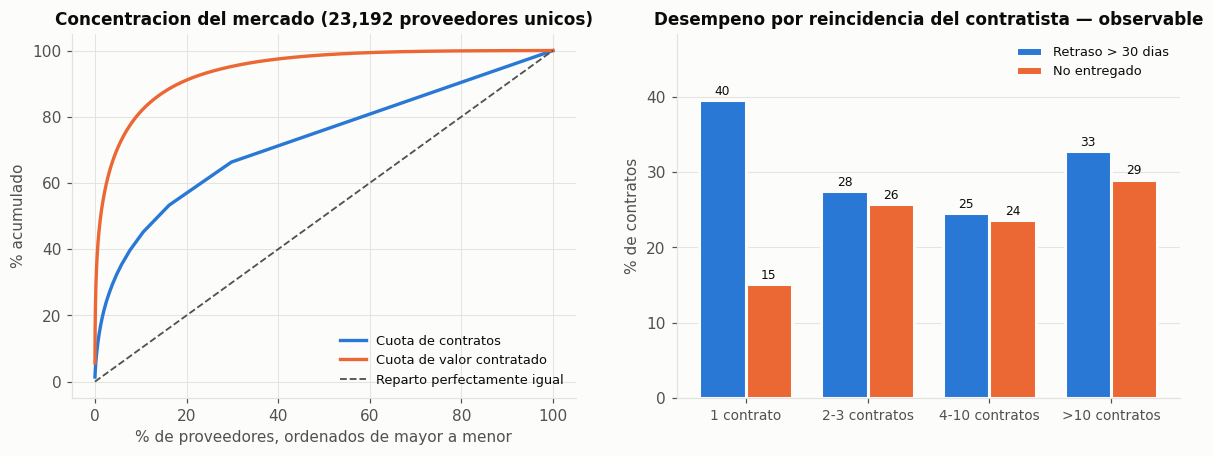

Figura persistida: 07_perfil_proveedor.png


In [10]:
marcar("fig_perfil")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
cum_contratos = np.cumsum(conteo.values) / conteo.sum() * 100
x_prov = np.arange(1, len(conteo) + 1) / len(conteo) * 100
ax.plot(x_prov, cum_contratos, lw=2.2, color=PALETA[0], label="Cuota de contratos")
cum_valor = np.cumsum(valor.values) / valor.sum() * 100
x_val = np.arange(1, len(valor) + 1) / len(valor) * 100
ax.plot(x_val, cum_valor, lw=2.2, color=PALETA[1], label="Cuota de valor contratado")
ax.plot([0, 100], [0, 100], lw=1.2, ls="--", color=TEXT_2, label="Reparto perfectamente igual")
ax.set_xlabel("% de proveedores, ordenados de mayor a menor")
ax.set_ylabel("% acumulado")
ax.set_title(f"Concentracion del mercado ({n_prov:,} proveedores unicos)", fontsize=11)
ax.legend(fontsize=8.5, loc="lower right"); ax.set_axisbelow(True)

ax = axes[1]
pr = perfil_reinc(obs2)
x = np.arange(len(ETIQ_R)); w = 0.38
ax.bar(x - w/2, pr["pct_retraso_mayor_30"], w, label="Retraso > 30 dias",
       color=PALETA[0], edgecolor=SURFACE, linewidth=2)
ax.bar(x + w/2, pr["pct_no_entregado"], w, label="No entregado",
       color=PALETA[1], edgecolor=SURFACE, linewidth=2)
for i, (a, b) in enumerate(zip(pr["pct_retraso_mayor_30"], pr["pct_no_entregado"])):
    ax.text(i - w/2, a + 0.7, f"{a:.0f}", ha="center", fontsize=8, color=TEXT_1)
    ax.text(i + w/2, b + 0.7, f"{b:.0f}", ha="center", fontsize=8, color=TEXT_1)
ax.set_xticks(x); ax.set_xticklabels(ETIQ_R, fontsize=9)
ax.set_ylabel("% de contratos")
ax.set_ylim(0, max(pr["pct_retraso_mayor_30"].max(), pr["pct_no_entregado"].max()) * 1.22)
ax.set_title("Desempeno por reincidencia del contratista — observable", fontsize=11)
ax.legend(fontsize=8.5); ax.xaxis.grid(False); ax.set_axisbelow(True)
guardar_mostrar(fig, "07_perfil_proveedor.png")

## 4. Categoria UNSPSC principal del proveedor

In [11]:
marcar("unspsc")

sub = obs[obs["prov_codigo_categoria_principal"].notna()]
print(f"N efectivo con categoria UNSPSC del registro: {len(sub):,} "
      f"({len(sub)/len(obs)*100:.1f}% del observable)")
print(f"Categorias distintas: {sub['prov_codigo_categoria_principal'].nunique():,}")
top = (sub.groupby("prov_codigo_categoria_principal")
       .agg(n=("id_contrato", "size"),
            mediana_valor=("valor_del_contrato", "median"),
            mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
            pct_no_entregado=("indice_alcance", lambda s: round((s == "No entregado").mean()*100, 1)))
       .sort_values("n", ascending=False).head(10))
print()
print(top.to_string())
print()
print("La categoria UNSPSC del PROVEEDOR describe su actividad principal declarada, no el objeto del")
print("contrato. Con 54% de cobertura y alta dispersion su valor analitico es limitado; se reporta por")
print("completitud del bloque de perfil y se declara como no concluyente.")

N efectivo con categoria UNSPSC del registro: 12,527 (65.3% del observable)
Categorias distintas: 45

                                     n    mediana_valor  mediana_deslizamiento  pct_no_entregado
prov_codigo_categoria_principal                                                                 
No Definido                      11866 140,516,938.5000                 0.0000           24.0000
V1.72100000                        243 287,440,744.0000                 0.0000           25.9000
V1.81100000                        140 197,073,078.5000                 1.0000           25.7000
V1.72120000                        110 791,232,279.0000                 6.0000           27.3000
V1.72150000                         41 243,243,659.0000                -1.0000           43.9000
V1.72140000                         25 362,345,000.0000                39.0000           32.0000
V1.95120000                         13 251,165,677.0000                 4.0000            7.7000
V1.72110000              

## 5. Sintesis de hallazgos etiquetados

In [12]:
reg = RegistroHallazgos("07")
r_pyme = mann_whitney(obs.loc[obs["es_pyme"] == "Si", "deslizamiento_plazo_dias"],
                      obs.loc[obs["es_pyme"] == "No", "deslizamiento_plazo_dias"], "PYME", "No PYME")
reg.add("H07-01",
        "`es_pyme` discrimina el desempeno de plazo: los contratos de PYME presentan menor deslizamiento que los de no PYME",
        resumen_prueba(r_pyme).split("\n")[0], ref("pyme"),
        ["A-OE04", "B-OE2", "B-OE3-insumo"], "Alto",
        "Cierra la brecha 7: la variable estaba disponible al 100% y sin usar. El efecto puede estar confundido con la cuantia")
reg.add("H07-02",
        "`es_pyme` del contrato y `espyme` del registro concuerdan al 100%: son la misma variable con coberturas distintas",
        f"Concordancia del {concordan:.2f}% sobre N efectivo {len(comp):,}", ref("pyme_coherencia"),
        ["CALIDAD", "A-OE02"], "Medio",
        "Valida la homologacion semantica entre las dos fuentes y justifica usar la version de cobertura completa")
reg.add("H07-02b",
        "La antiguedad del proveedor no es calculable para consorcios y uniones temporales: no figuran en el registro externo",
        "Tabla de cobertura de antiguedad por tipo de contratista", ref("pyme_coherencia"),
        ["CALIDAD"], "Alto",
        "Sesga por construccion cualquier analisis de antiguedad hacia personas juridicas y naturales; afecta a A-H2")
reg.add("H07-03",
        "El mercado de obra publica tiene cola larga: la mayoria de los proveedores tiene un unico contrato y no hay contratistas dominantes",
        f"{int((conteo == 1).sum()):,} proveedores con un solo contrato ({(conteo == 1).mean()*100:.1f}%); top 10 acumula {round(conteo.head(10).sum()/conteo.sum()*100, 2)}% de los contratos",
        ref("concentracion"), ["B-OE2", "A-OE04"], "Alto",
        "Contradice la expectativa de captura del mercado por pocos contratistas")
reg.add("H07-04",
        "La reincidencia del contratista se asocia al desempeno: los proveedores con mas contratos muestran mayor retraso material",
        "Kruskal-Wallis y chi-cuadrado con tamano de efecto reportados", ref("reincidencia"),
        ["B-OE2", "B-OE3-insumo", "A-OE04"], "Alto",
        "Variable derivable sin fuentes externas; candidata a informar cualquier priorizacion de vigilancia")
reg.add("H07-05",
        "La antiguedad del proveedor mide antiguedad de la CUENTA en SECOP, no antiguedad empresarial",
        f"N efectivo {int(df['antiguedad_proveedor_anios'].notna().sum()):,}; maximo observado en torno a 11 anios, coherente con la vida de la plataforma",
        ref("antiguedad"), ["CALIDAD"], "Alto",
        "Impide interpretarla como experiencia del contratista; corrige una lectura probable del campo")
reg.add("H07-06",
        "El tipo de empresa del registro discrimina el desempeno de plazo entre las formas societarias principales",
        "Kruskal-Wallis entre los 8 tipos de empresa mas frecuentes, con N efectivo declarado",
        ref("tipo_empresa"), ["B-OE2", "B-OE3-insumo"], "Medio",
        "Cobertura limitada al 54% de los proveedores; se reporta con su N efectivo")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H07-01,07,c004,`es_pyme` discrimina el desempeno de plazo: lo...,"Mann-Whitney U = 24,323,628.0 | p = 8.42e-157 ...",[A-OE04] [B-OE2] [B-OE3-insumo],Alto,Cierra la brecha 7: la variable estaba disponi...
1,H07-02,07,c005,`es_pyme` del contrato y `espyme` del registro...,"Concordancia del 100.00% sobre N efectivo 32,126",[CALIDAD] [A-OE02],Medio,Valida la homologacion semantica entre las dos...
2,H07-02b,07,c005,La antiguedad del proveedor no es calculable p...,Tabla de cobertura de antiguedad por tipo de c...,[CALIDAD],Alto,Sesga por construccion cualquier analisis de a...
3,H07-03,07,c009,El mercado de obra publica tiene cola larga: l...,"16,299 proveedores con un solo contrato (70.3%...",[B-OE2] [A-OE04],Alto,Contradice la expectativa de captura del merca...
4,H07-04,07,c010,La reincidencia del contratista se asocia al d...,Kruskal-Wallis y chi-cuadrado con tamano de ef...,[B-OE2] [B-OE3-insumo] [A-OE04],Alto,Variable derivable sin fuentes externas; candi...
5,H07-05,07,c008,La antiguedad del proveedor mide antiguedad de...,"N efectivo 28,947; maximo observado en torno a...",[CALIDAD],Alto,Impide interpretarla como experiencia del cont...
6,H07-06,07,c007,El tipo de empresa del registro discrimina el ...,Kruskal-Wallis entre los 8 tipos de empresa ma...,[B-OE2] [B-OE3-insumo],Medio,Cobertura limitada al 54% de los proveedores; ...


## Sintesis del notebook 07

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H07-01 | `es_pyme` discrimina el desempeno de plazo; la variable estaba disponible al 100% y sin usar | `[A-OE04]` `[B-OE2]` `[B-OE3-insumo]` |
| H07-02 | `es_pyme` del contrato y `espyme` del registro concuerdan al 100%: misma variable, coberturas distintas | `[CALIDAD]` `[A-OE02]` |
| H07-02b | La antiguedad no es calculable para consorcios y uniones temporales | `[CALIDAD]` |
| H07-03 | El mercado tiene cola larga: no hay contratistas dominantes | `[B-OE2]` `[A-OE04]` |
| H07-04 | La reincidencia del contratista se asocia al desempeno | `[B-OE2]` `[B-OE3-insumo]` `[A-OE04]` |
| H07-05 | La antiguedad medible es antiguedad de la cuenta en SECOP, no experiencia empresarial | `[CALIDAD]` |
| H07-06 | El tipo de empresa discrimina el desempeno de plazo, con cobertura limitada | `[B-OE2]` `[B-OE3-insumo]` |

**Producto persistido:** `figuras/07_perfil_proveedor.png`.

**Advertencia de interpretacion.** Ninguno de los efectos de este cuaderno esta controlado por cuantia.
Dado que la cuantia se asocia tanto al perfil del contratista como al desempeno (notebook 05), los
efectos reportados aqui son asociaciones brutas. Se declara explicitamente y se remite al notebook 10,
donde el control por estratificacion se aplica a las hipotesis formales.